In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/admission.csv")
print(df.head())

   GRE Score  TOEFL Score  University Rating  SOP  LOR    GPA  Research  \
0        295           96                  2  4.9   1.7  2.93         0   
1        340          119                  3  4.1   1.7  3.76         0   
2        336           96                  1  3.2   1.8  3.12         1   
3        337          108                  4  3.4   1.3  2.11         0   
4        323           98                  1  1.1   1.3  3.40         0   

   Chance of Admit  
0            0.612  
1            0.708  
2            0.728  
3            0.643  
4            0.524  


In [3]:
df.shape

(1000, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          1000 non-null   int64  
 1   TOEFL Score        1000 non-null   int64  
 2   University Rating  1000 non-null   int64  
 3   SOP                1000 non-null   float64
 4   LOR                1000 non-null   float64
 5   GPA                1000 non-null   float64
 6   Research           1000 non-null   int64  
 7   Chance of Admit    1000 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 62.6 KB


In [5]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,GPA,Research,Chance of Admit
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,315.840000,106.459000,3.053000,2.997000,3.014400,3.027160,0.517000,0.729223
std,15.083432,8.449954,1.421341,1.163239,1.163136,0.582774,0.499961,0.095161
min,290.000000,92.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.491000
25%,303.000000,99.000000,2.000000,2.000000,2.000000,2.530000,0.000000,0.655000
50%,316.000000,107.000000,3.000000,3.000000,3.000000,3.025000,1.000000,0.728500
75%,329.000000,114.000000,4.000000,4.000000,4.000000,3.550000,1.000000,0.801000
max,340.000000,120.000000,5.000000,5.000000,5.000000,4.000000,1.000000,0.970000


In [6]:
df.isnull().sum()

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
GPA                  0
Research             0
Chance of Admit      0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)
df.shape

(1000, 8)

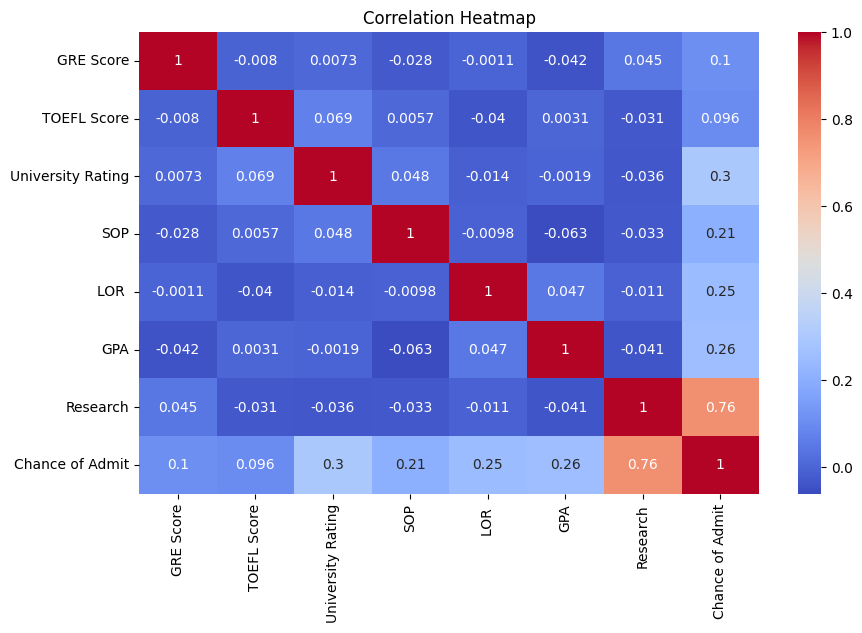

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Features (input)
X = df.drop(columns=["Chance of Admit"])

# Target (output)
y = df["Chance of Admit"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [13]:
score = model.score(X_test, y_test)
print("Accuracy:", score)

Accuracy: 0.9027598383788027


In [14]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("Predicted Chance:", prediction[0])

Predicted Chance: 0.7768935066278099


In [15]:
import pickle

pickle.dump(model, open("../backend/model/model.pkl", "wb"))
pickle.dump(scaler, open("../backend/model/scaler.pkl", "wb"))